# PPMI cohort exploration

Optional, best-effort descriptive analysis of the per-image metadata table
saved by `ppmi_imaging_exploration.ipynb` (`extra.merged_csv`) -- demographics,
diagnosis/cohort breakdowns, longitudinal coverage, multimodal availability.
Nothing in the rest of the pipeline depends on this notebook; it's for
understanding the data before deciding on a cohort selection, not a
prerequisite for BIDS conversion.


## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from upsetplot import UpSet, from_indicators

from mri_prep.config import REPO_ROOT, load_dataset_config
from mri_prep.datasets.ppmi import COHORT_MAP, EVENT_ID_TO_VISIT, PRIMDIAG_MAP, visit_sort_key

%matplotlib inline

config = load_dataset_config("ppmi")
df = pd.read_csv(REPO_ROOT / config.extra["merged_csv"], low_memory=False, dtype={"PATNO": str})
df["Study Date"] = pd.to_datetime(df["Study Date"], errors="coerce")
if "PRIMDIAG_DESC" not in df.columns:
    df["PRIMDIAG_DESC"] = df["PRIMDIAG"].map(PRIMDIAG_MAP)
if "COHORT_DESC" not in df.columns:
    df["COHORT_DESC"] = df["COHORT"].map(COHORT_MAP)
print(f"Rows: {len(df)}, subjects: {df['PATNO'].nunique()}")

Rows: 69508, subjects: 7916


## Plotting helpers

No package equivalent (notebook-only convenience), ported from the old
`ppmi_utils.py`.

In [2]:
def plot_bar(df, col, title=None, figsize=(6, 4), annotate=True):
    """Bar plot for a categorical column with counts annotated on top,
    missing values shown as their own bar."""
    if not title:
        title = f"Counts of {col}"
    counts = df[col].value_counts(dropna=False).sort_values(ascending=False)
    labels = counts.index.to_series().fillna("MISSING VALUES (NA)").astype(str)

    plt.figure(figsize=figsize)
    ax = sns.barplot(x=labels, y=counts.values, hue=labels, legend=False, palette="viridis")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    if annotate:
        for i, v in enumerate(counts.values):
            if v > 0:
                ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_hist(df, col, title=None):
    if not title:
        title = f"Distribution of {col}"
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(df[col], bins=30, kde=False)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Count")
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                height + 0.5,
                int(height),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.show()

## Age at baseline

               count       mean       std        min        25%        50%  \
age_at_visit  4788.0  65.343325  8.613249  20.726027  61.155479  66.156164   

                    75%        max  
age_at_visit  70.928767  91.405479  


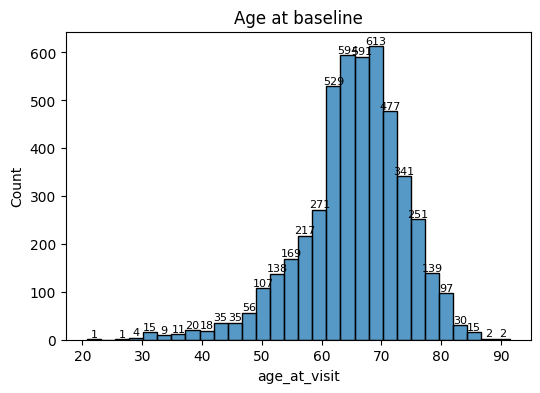

In [3]:
baseline_df = df[df["EVENT_ID"] == "BL"].copy()
baseline_unique = baseline_df.drop_duplicates(subset=["PATNO"])
print(baseline_unique[["age_at_visit"]].describe().T)
plot_hist(baseline_unique, "age_at_visit", title="Age at baseline")

## Sex distribution

Sex
M      3493
F      3452
X       815
NaN     156
Name: count, dtype: int64


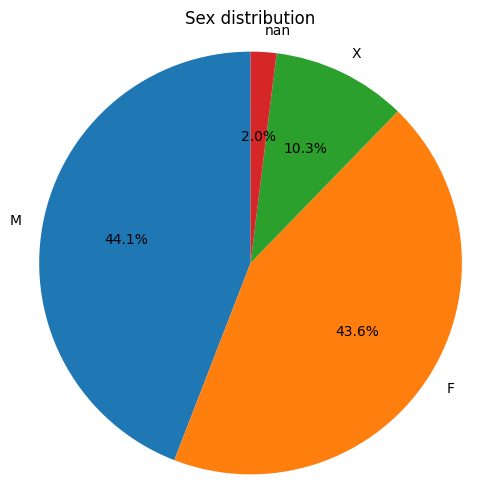

In [4]:
sex_per_patient = df.groupby("PATNO")["Sex"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)
sex_counts = sex_per_patient.value_counts(dropna=False)
print(sex_counts)

plt.figure(figsize=(6, 6))
plt.pie(sex_counts, labels=sex_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Sex distribution")
plt.axis("equal")
plt.show()

## Cohort / diagnosis distribution

Cohort definitions (PPMI study design):
1. **Parkinson's Disease** -- formal PD diagnosis.
2. **Prodromal** -- at risk of PD based on clinical features, genetic
   variants or other biomarkers, not formally diagnosed.
3. **Healthy Control** -- no neurologic disorder, no first-degree relative
   with PD.
4. **SWEDD** (Scan Without Dopaminergic Deficit) -- small legacy cohort, see
   https://www.ppmi-info.org/study-design/study-cohorts#legacy/

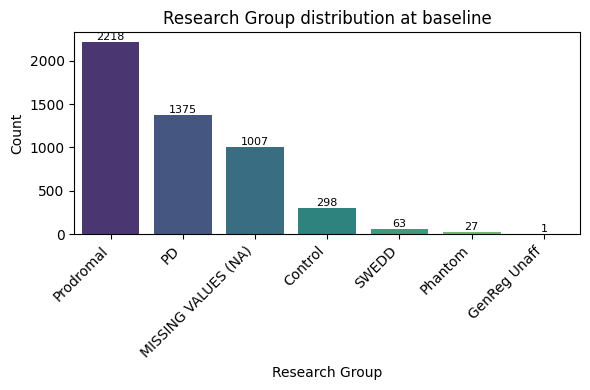

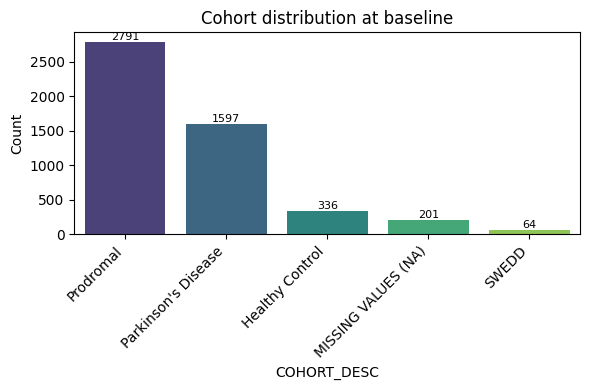

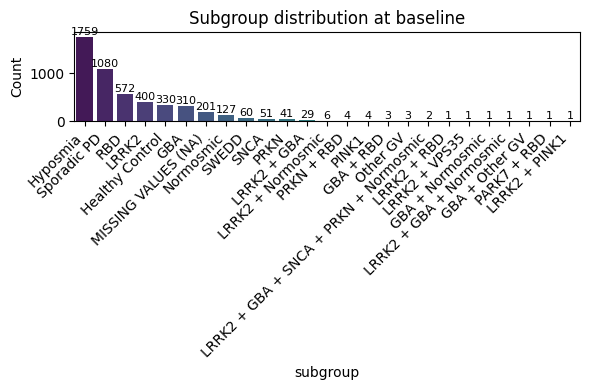

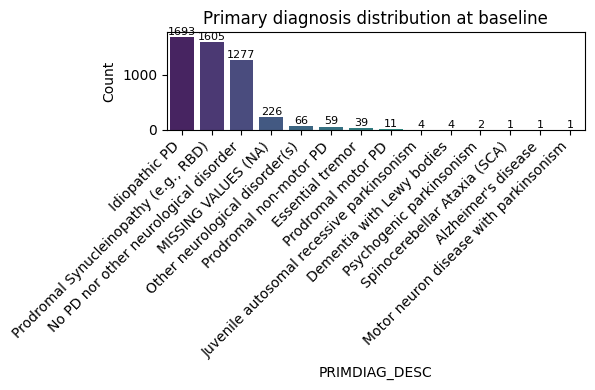

In [5]:
plot_bar(baseline_unique, "Research Group", title="Research Group distribution at baseline")
plot_bar(baseline_unique, "COHORT_DESC", title="Cohort distribution at baseline")
if "subgroup" in baseline_unique.columns:
    plot_bar(baseline_unique, "subgroup", title="Subgroup distribution at baseline")
plot_bar(baseline_unique, "PRIMDIAG_DESC", title="Primary diagnosis distribution at baseline")

## Longitudinal coverage

           count      mean       std  min  25%  50%  75%   max
EVENT_ID  7916.0  3.327564  3.225562  1.0  1.0  2.0  4.0  18.0


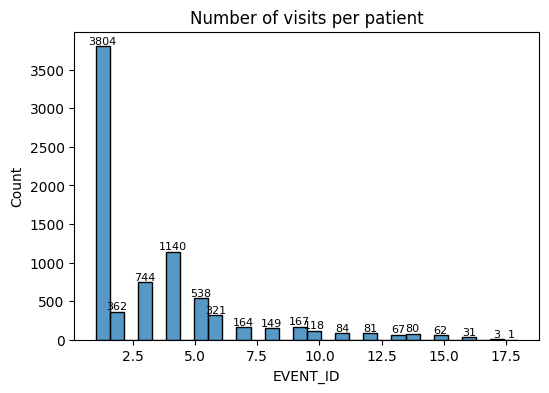

In [6]:
visits_per_patient = df.groupby("PATNO")["EVENT_ID"].nunique()
print(visits_per_patient.describe().to_frame().T)
plot_hist(visits_per_patient.reset_index(), "EVENT_ID", title="Number of visits per patient")

/home/falconnier/.cache/uv/archive-v0/W0Vmqlu1cKTLXSOf/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/falconnier/.cache/uv/archive-v0/W0Vmqlu1cKTLXSOf/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the in

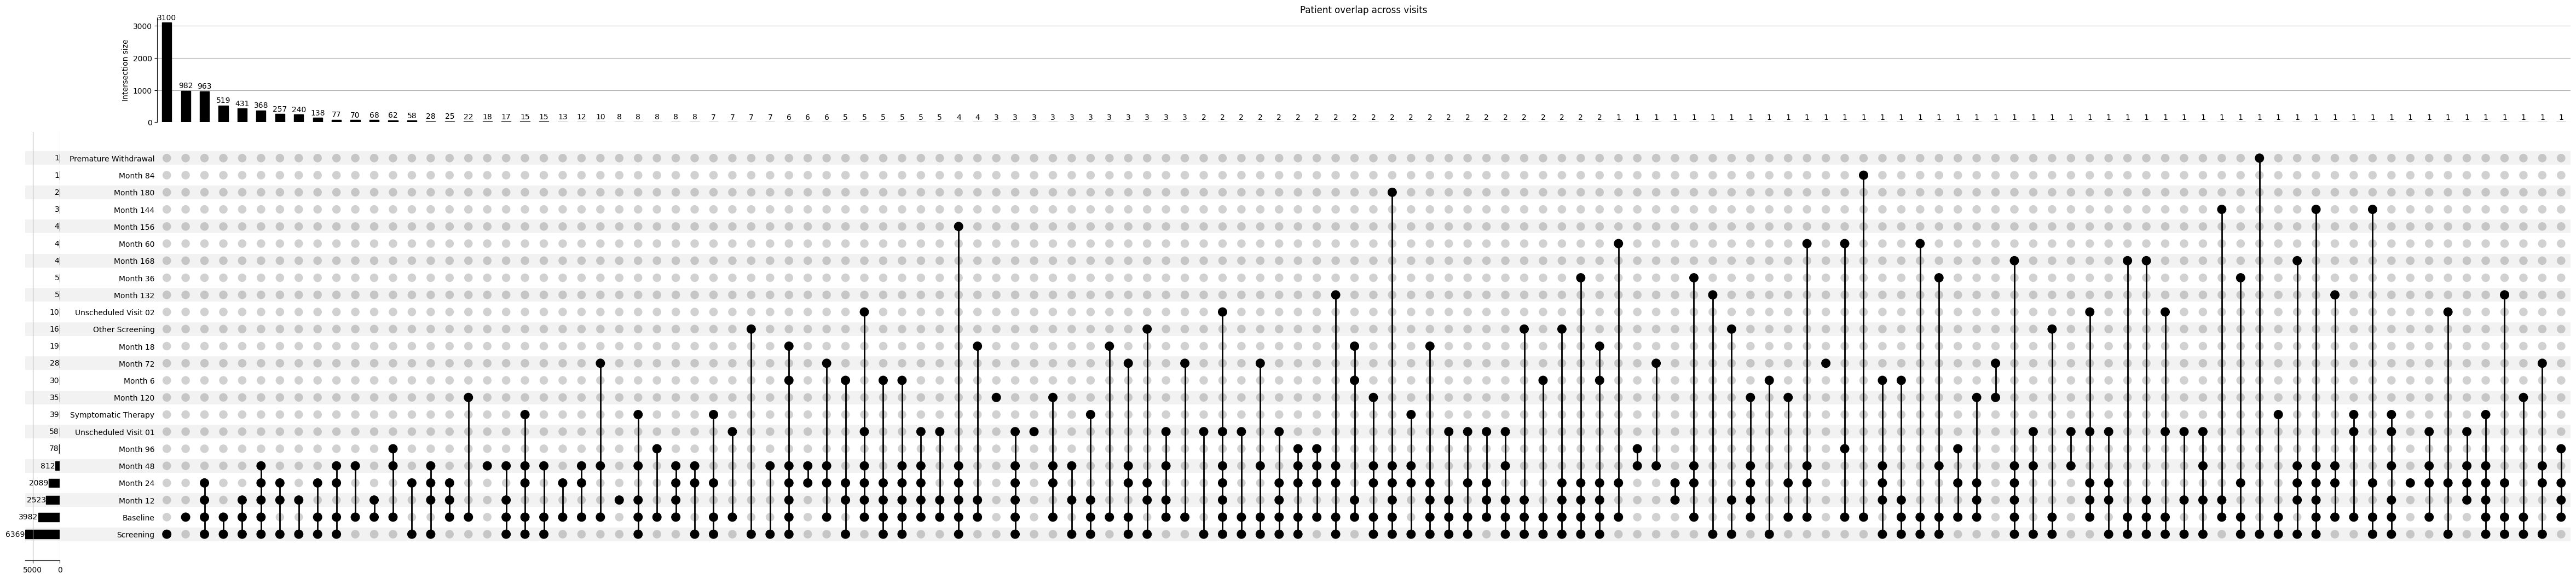

In [7]:
df_unique = df[["PATNO", "Visit"]].dropna().drop_duplicates()
df_binary = (
    df_unique.assign(value=1)
    .pivot_table(index="PATNO", columns="Visit", values="value", fill_value=0)
    .astype(bool)
)
upset_data = from_indicators(df_binary.columns.tolist(), df_binary)
upset = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality")
upset.plot()
plt.title("Patient overlap across visits")
plt.show()

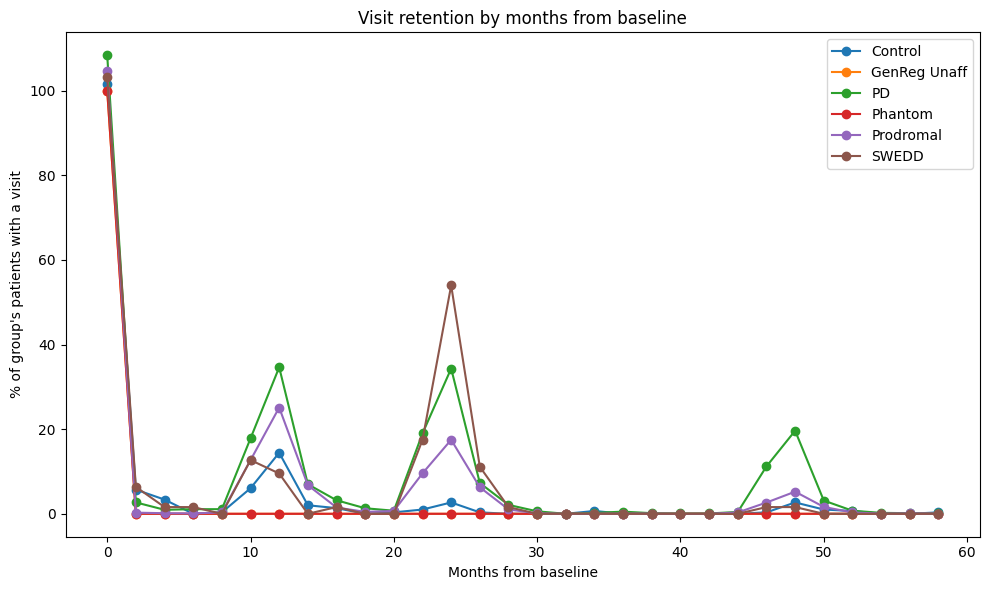

In [8]:
visit_dates = df.dropna(subset=["Study Date"]).drop_duplicates(subset=["PATNO", "EVENT_ID"])
baseline_dates = visit_dates[visit_dates["EVENT_ID"] == "BL"].groupby("PATNO")["Study Date"].min()
visit_dates = visit_dates.copy()
visit_dates["baseline_date"] = visit_dates["PATNO"].map(baseline_dates)
visit_dates["months_from_baseline"] = (
    visit_dates["Study Date"] - visit_dates["baseline_date"]
).dt.days / 30.44
visit_dates = visit_dates[visit_dates["months_from_baseline"] >= 0]

bins = np.arange(0, 61, 2)
plt.figure(figsize=(10, 6))
for group_name, group_df in visit_dates.groupby("Research Group"):
    n_patients = group_df["PATNO"].nunique()
    counts, bin_edges = np.histogram(group_df["months_from_baseline"], bins=bins)
    plt.plot(bin_edges[:-1], counts / n_patients * 100, marker="o", label=group_name)
plt.title("Visit retention by months from baseline")
plt.xlabel("Months from baseline")
plt.ylabel("% of group's patients with a visit")
plt.legend()
plt.tight_layout()
plt.show()

## Multimodal availability per visit

/tmp/ipykernel_163372/1727116940.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  ax = sns.barplot(x=summary["n_visits"], y=summary.index, hue=summary.index, legend=False, color="steelblue")


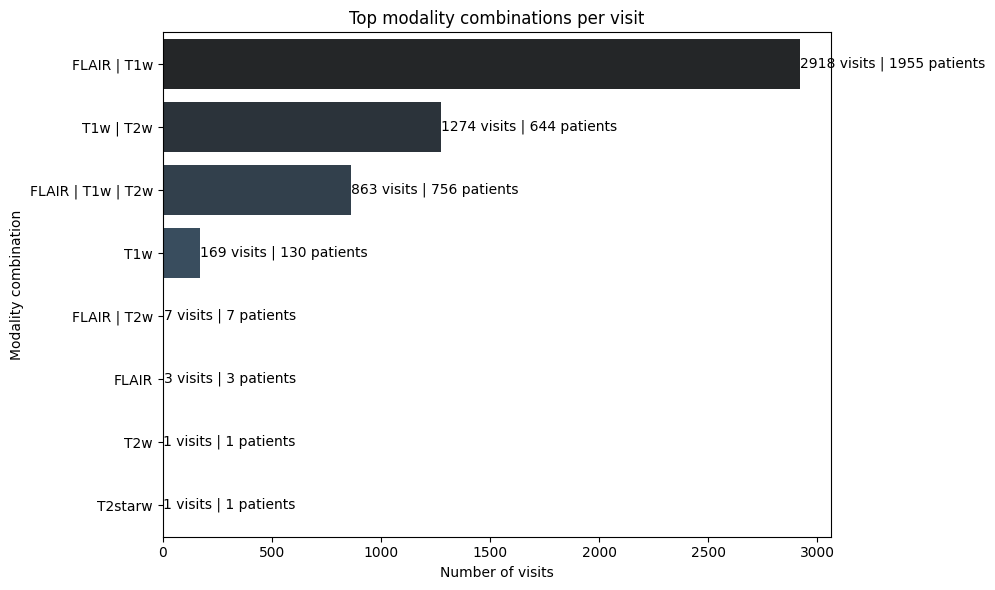

In [9]:
visit_modalities = (
    df.dropna(subset=["Advanced_Modality"])
    .groupby(["PATNO", "EVENT_ID"])["Advanced_Modality"]
    .unique()
    .reset_index()
)
visit_modalities["modality_combo"] = visit_modalities["Advanced_Modality"].apply(
    lambda x: " | ".join(sorted(x))
)
visit_counts = visit_modalities["modality_combo"].value_counts()
patient_counts = visit_modalities.groupby("modality_combo")["PATNO"].nunique()
summary = visit_counts.to_frame("n_visits").join(patient_counts.to_frame("n_patients"))
summary = summary.sort_values("n_visits", ascending=False).head(8)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=summary["n_visits"], y=summary.index, hue=summary.index, legend=False, color="steelblue")
for i, (visits, patients) in enumerate(zip(summary["n_visits"], summary["n_patients"])):
    ax.text(visits + 1, i, f"{visits} visits | {patients} patients", va="center")
plt.title("Top modality combinations per visit")
plt.xlabel("Number of visits")
plt.ylabel("Modality combination")
plt.tight_layout()
plt.show()